# BiLSTM Prediction Pipeline

This notebook runs the same technical-indicator time-series prediction workflow as `TS_Prediction_Pipeline.ipynb`, but replaces the model layer with `biLSTM.py`.

Pipeline modules:
- `indicator.py`: technical indicators and Pearson IC feature selection
- `tensor_transform.py`: 3-D tensor construction `(batch, time_steps, input_features)`
- `biLSTM.py`: original bidirectional LSTM model with forward/backward hidden-state concatenation
- `plot_results.py`: tensor and predicted-close plots


In [12]:
from pathlib import Path
import importlib
import json

import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import Image, display

import biLSTM
import indicator
import tensor_transform
import plot_results

# Jupyter keeps imported modules cached. Reload project scripts after edits.
importlib.reload(biLSTM)
importlib.reload(indicator)
importlib.reload(tensor_transform)
importlib.reload(plot_results)

from biLSTM import BiLSTMPredictor
from indicator import add_technical_indicators, select_features_by_ic
from tensor_transform import build_lstm_tensors
from plot_results import plot_tensor_surface, plot_price_predictions

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [13]:
INDEX_TICKERS = {
    "Nasdaq": "^IXIC",
    "SP500": "^GSPC",
    "SOX": "^SOX",
}

START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
# 21 trading days is approximately one month. The input window still updates every trading day.
HORIZON = 1
TOP_K = 16
EPOCHS = 80

OUTPUT_DIR = Path(f"outputs_bilstm_h{HORIZON}")
PLOTS_DIR = Path(f"plots_bilstm_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this to False if you only want to reload existing CSV outputs and regenerate plots.
RUN_TRAINING = True


## BiLSTM Benchmark Helpers

In [14]:
def download_index(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
    if df.empty:
        raise RuntimeError(f"No data downloaded for {ticker}")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    return df


def regression_metrics(actual: np.ndarray, predicted: np.ndarray, naive: np.ndarray) -> dict[str, float]:
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    naive = np.asarray(naive)
    rmse = float(np.sqrt(np.mean((predicted - actual) ** 2)))
    mae = float(np.mean(np.abs(predicted - actual)))
    mape = float(np.mean(np.abs((predicted - actual) / actual)) * 100.0)
    naive_rmse = float(np.sqrt(np.mean((naive - actual) ** 2)))
    naive_mae = float(np.mean(np.abs(naive - actual)))
    return {
        "rmse": rmse,
        "mae": mae,
        "mape_pct": mape,
        "naive_rmse": naive_rmse,
        "naive_mae": naive_mae,
        "rmse_vs_naive_pct": float((1.0 - rmse / naive_rmse) * 100.0) if naive_rmse else np.nan,
        "mae_vs_naive_pct": float((1.0 - mae / naive_mae) * 100.0) if naive_mae else np.nan,
    }


def direction_accuracy(actual: pd.Series, predicted: pd.Series, previous_close: pd.Series) -> float:
    actual_direction = np.sign(actual.to_numpy() - previous_close.to_numpy())
    predicted_direction = np.sign(predicted.to_numpy() - previous_close.to_numpy())
    return float((actual_direction == predicted_direction).mean() * 100.0)


In [15]:
def run_bilstm_benchmark(
    name: str,
    ticker: str,
    start: str,
    end: str,
    train_end: str,
    test_start: str,
    test_end: str,
    lookback: int,
    horizon: int,
    top_k: int,
    epochs: int,
    output_dir: Path,
) -> dict:
    raw = download_index(ticker, start=start, end=end)
    features_df = add_technical_indicators(raw)

    train_features_df = features_df.loc[:train_end]
    selection = select_features_by_ic(train_features_df, horizon=horizon, top_k=top_k)
    tensor_data = build_lstm_tensors(
        features_df,
        feature_columns=selection.features,
        lookback=lookback,
        horizon=horizon,
        train_end=train_end,
        test_start=test_start,
        test_end=test_end,
        target_mode="log_return",
    )

    model = BiLSTMPredictor(input_size=len(selection.features))
    history = model.fit(tensor_data.X_train, tensor_data.y_train, epochs=epochs)

    pred_scaled = model.predict(tensor_data.X_test)
    predicted_return = tensor_data.inverse_target(pred_scaled)
    actual_return = tensor_data.inverse_target(tensor_data.y_test)
    predicted = tensor_data.test_base_values * np.exp(predicted_return)
    actual = tensor_data.test_base_values * np.exp(actual_return)
    test_dates = tensor_data.test_dates
    baseline = tensor_data.test_base_values

    prediction_df = pd.DataFrame(
        {
            "forecast_base_date": tensor_data.test_base_dates,
            "date": test_dates,
            "index": name,
            "ticker": ticker,
            "model": "BiLSTM",
            "horizon_trading_days": horizon,
            "actual_close": actual,
            "predicted_close": predicted,
            "naive_previous_close": baseline,
            "actual_log_return": actual_return,
            "predicted_log_return": predicted_return,
            "absolute_error": np.abs(predicted - actual),
            "pct_error": np.abs((predicted - actual) / actual) * 100.0,
        }
    )
    prediction_df.to_csv(output_dir / f"{name}_predictions.csv", index=False)

    metrics = regression_metrics(actual, predicted, baseline)
    metrics["direction_accuracy_pct"] = direction_accuracy(
        pd.Series(actual, index=test_dates),
        pd.Series(predicted, index=test_dates),
        pd.Series(baseline, index=test_dates),
    )
    metrics["samples"] = int(len(actual))
    metrics["train_samples"] = int(len(tensor_data.y_train))
    metrics["features"] = selection.features
    metrics["final_train_loss"] = history.train_loss[-1]
    metrics["final_val_loss"] = history.val_loss[-1]

    selection.scores.to_csv(output_dir / f"{name}_feature_ic.csv", index=False)
    raw.to_csv(output_dir / f"{name}_raw.csv")
    return {"index": name, "ticker": ticker, "model": "BiLSTM", **metrics}


## Train BiLSTM And Build Benchmark Outputs

The target is horizon log return. Predicted log return is converted back to close price with:

```text
predicted_close = previous_close * exp(predicted_log_return)
```


In [16]:
if RUN_TRAINING:
    results = []
    for index_name, ticker in INDEX_TICKERS.items():
        print(f"Running BiLSTM {index_name} ({ticker})...")
        result = run_bilstm_benchmark(
            name=index_name,
            ticker=ticker,
            start=START,
            end=END,
            train_end=TRAIN_END,
            test_start=TEST_START,
            test_end=TEST_END,
            lookback=LOOKBACK,
            horizon=HORIZON,
            top_k=TOP_K,
            epochs=EPOCHS,
            output_dir=OUTPUT_DIR,
        )
        results.append(result)
        print(
            f"{index_name}: RMSE={result['rmse']:.2f}, MAE={result['mae']:.2f}, "
            f"MAPE={result['mape_pct']:.2f}%, Direction={result['direction_accuracy_pct']:.2f}%"
        )

    summary = pd.DataFrame(results)
    summary.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)
    (OUTPUT_DIR / "benchmark_summary.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
else:
    print("Skipped training. Loading existing BiLSTM benchmark outputs.")


Running BiLSTM Nasdaq (^IXIC)...
Nasdaq: RMSE=263.85, MAE=208.94, MAPE=0.89%, Direction=59.80%
Running BiLSTM SP500 (^GSPC)...
SP500: RMSE=57.85, MAE=44.63, MAPE=0.65%, Direction=56.86%
Running BiLSTM SOX (^SOX)...
SOX: RMSE=229.59, MAE=176.93, MAPE=1.95%, Direction=66.67%


## Benchmark Summary

In [17]:
summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
metric_cols = [
    "index", "ticker", "model", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct", "direction_accuracy_pct",
]
summary[metric_cols]


,index,ticker,model,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct
0,Nasdaq,^IXIC,BiLSTM,102,3935,263.846771,208.936905,0.894078,265.655243,212.978714,0.680759,1.897753,59.803922
1,SP500,^GSPC,BiLSTM,102,3935,57.853897,44.634636,0.647348,58.252670,44.949261,0.684558,0.699955,56.862745
2,SOX,^SOX,BiLSTM,102,3935,229.586624,176.926697,1.951683,232.848099,180.839172,1.400688,2.163511,66.666667


## Inspect Feature IC Ranking

In [18]:
feature_ic = {
    index_name: pd.read_csv(OUTPUT_DIR / f"{index_name}_feature_ic.csv").head(TOP_K)
    for index_name in summary["index"]
}
feature_ic["Nasdaq"]


,feature,ic,abs_ic
0,Low,0.999640,0.999640
1,High,0.999632,0.999632
2,Open,0.999549,0.999549
3,MA_5,0.999406,0.999406
4,EMA_12,0.999116,0.999116
5,MA_10,0.999029,0.999029
6,EMA_26,0.998329,0.998329
7,MA_20,0.998256,0.998256
8,MA_60,0.995249,0.995249
9,Volume,0.882157,0.882157


## Build One Tensor Manually From Imported Scripts

This cell verifies the exact tensor shape consumed by `BiLSTMPredictor`: `(samples, lookback, selected_features)`.


In [19]:
example_index = "Nasdaq"
raw = pd.read_csv(OUTPUT_DIR / f"{example_index}_raw.csv", index_col=0, parse_dates=True)
features_df = add_technical_indicators(raw)
selected_features = pd.read_csv(OUTPUT_DIR / f"{example_index}_feature_ic.csv")["feature"].head(TOP_K).tolist()

tensor_data = build_lstm_tensors(
    features_df,
    feature_columns=selected_features,
    lookback=LOOKBACK,
    horizon=HORIZON,
    train_end=TRAIN_END,
    test_start=TEST_START,
    test_end=TEST_END,
    target_mode="log_return",
)

print("X_train:", tensor_data.X_train.shape)
print("y_train:", tensor_data.y_train.shape)
print("X_test:", tensor_data.X_test.shape)
print("y_test:", tensor_data.y_test.shape)
print("features:", tensor_data.feature_columns)


X_train: (3935, 30, 16)
y_train: (3935,)
X_test: (102, 30, 16)
y_test: (102,)
features: ['Low', 'High', 'Open', 'MA_5', 'EMA_12', 'MA_10', 'EMA_26', 'MA_20', 'MA_60', 'Volume', 'MACD_signal', 'MACD', 'Volatility_10', 'Close_to_MA_60', 'HL_range_pct', 'Close_to_EMA_26']


## Generate Matplotlib Plots

In [20]:
for index_name in summary["index"]:
    plot_tensor_surface(
        index_name=index_name,
        raw_path=OUTPUT_DIR / f"{index_name}_raw.csv",
        feature_ic_path=OUTPUT_DIR / f"{index_name}_feature_ic.csv",
        output_path=PLOTS_DIR / f"{index_name}_tensor_3d.png",
        lookback=LOOKBACK,
        horizon=HORIZON,
        top_k=TOP_K,
        train_end=TRAIN_END,
        test_start=TEST_START,
        test_end=TEST_END,
    )
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )

sorted(PLOTS_DIR.glob("*.png"))


[PosixPath('plots_bilstm_h1/Nasdaq_price_prediction.png'),
 PosixPath('plots_bilstm_h1/Nasdaq_tensor_3d.png'),
 PosixPath('plots_bilstm_h1/SOX_price_prediction.png'),
 PosixPath('plots_bilstm_h1/SOX_tensor_3d.png'),
 PosixPath('plots_bilstm_h1/SP500_price_prediction.png'),
 PosixPath('plots_bilstm_h1/SP500_tensor_3d.png')]

## 3-D Tensor Plots

Nasdaq


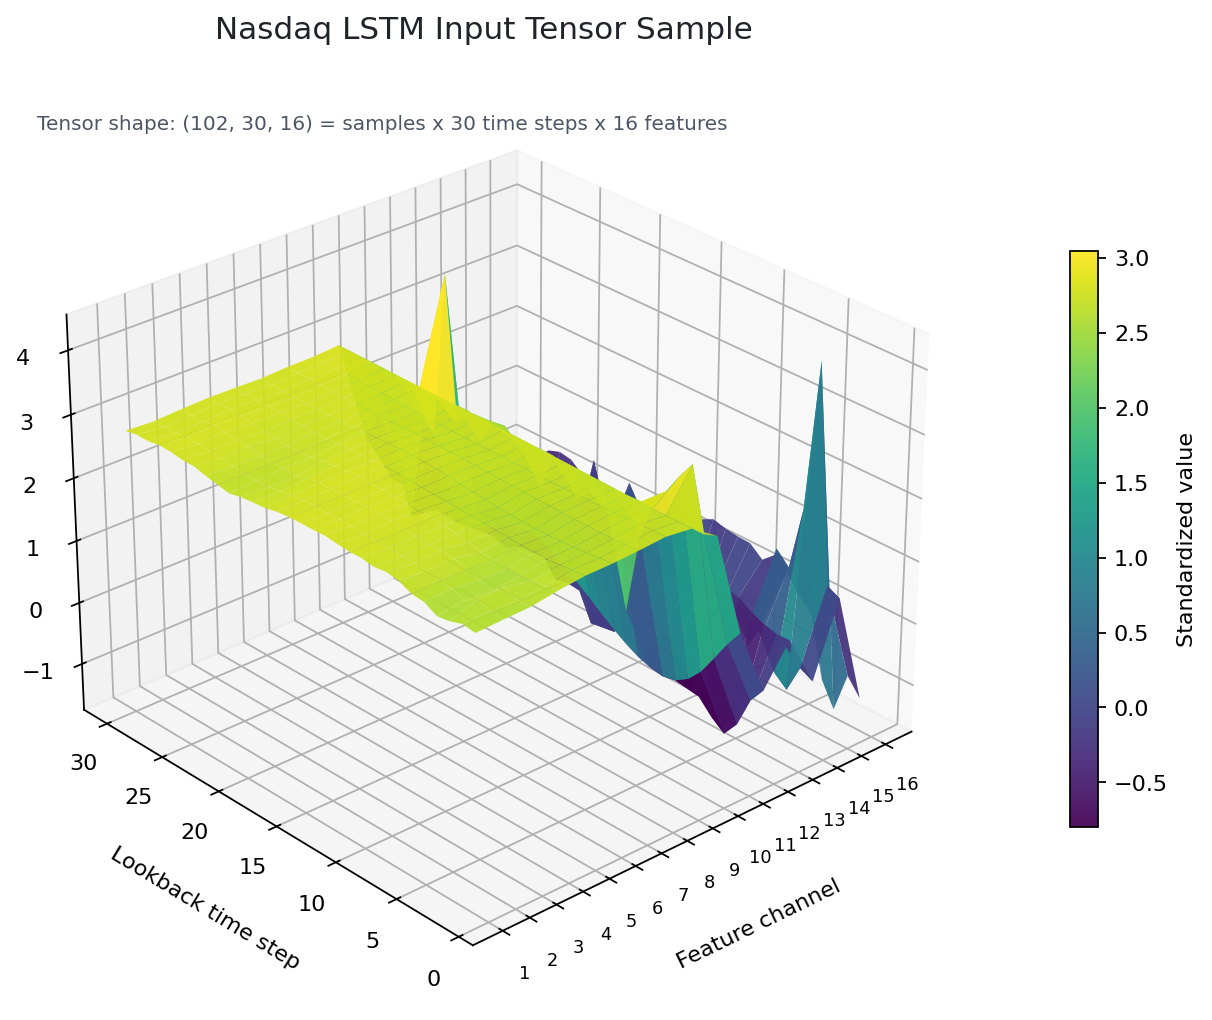

SP500


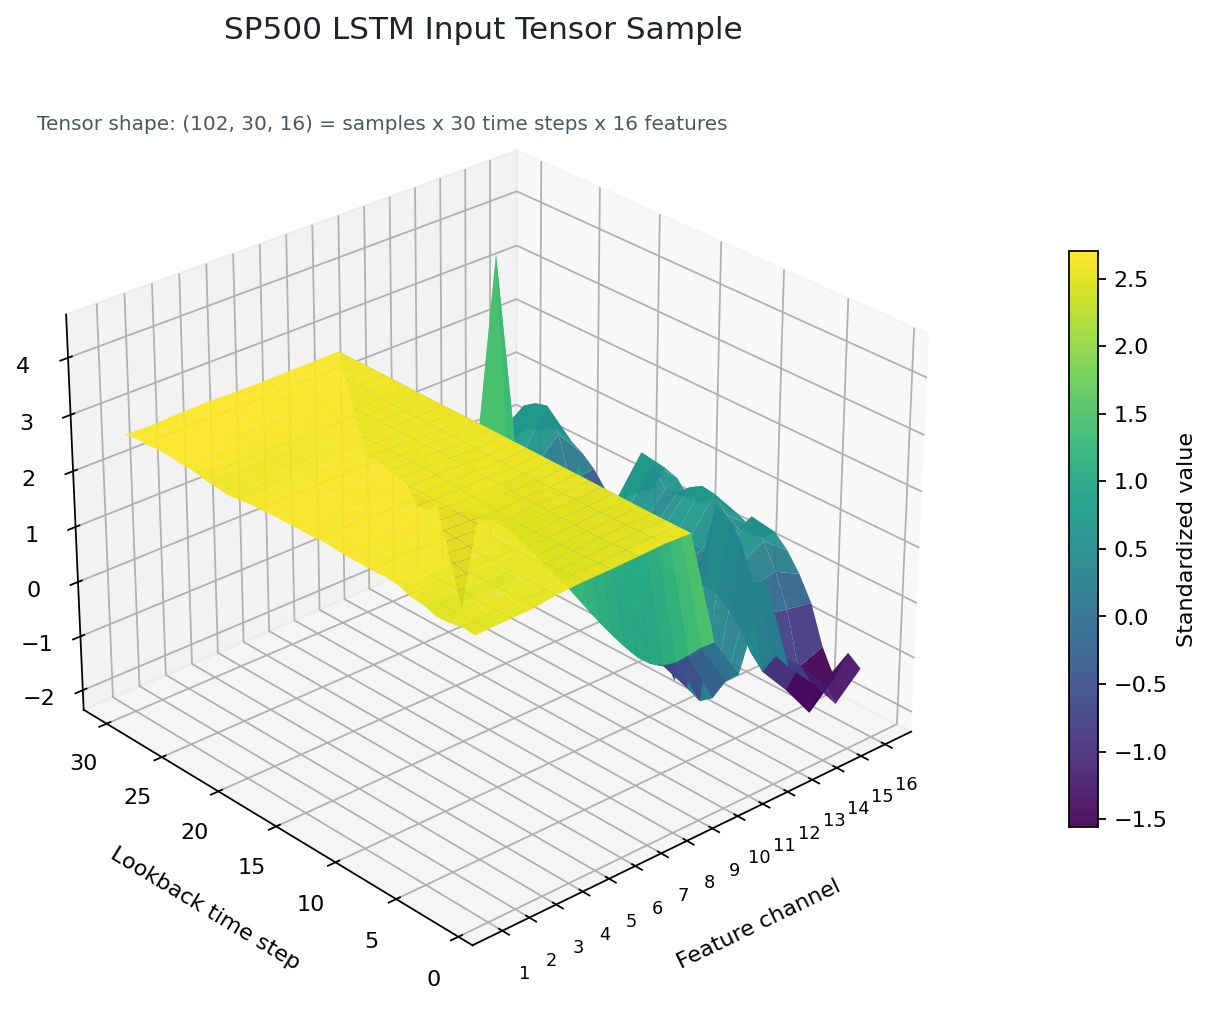

SOX


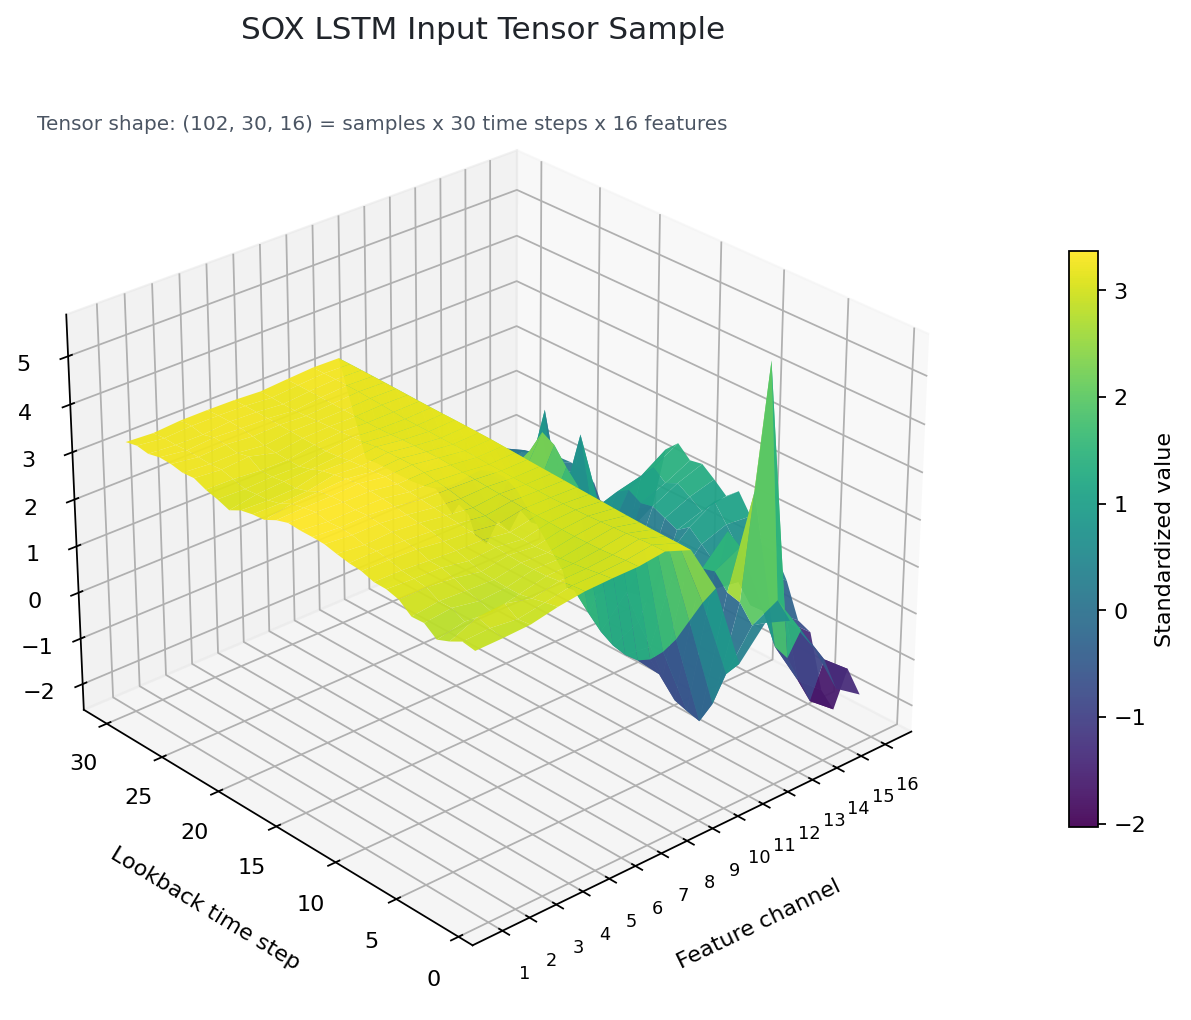

In [21]:
for index_name in summary["index"]:
    print(index_name)
    display(Image(filename=str(PLOTS_DIR / f"{index_name}_tensor_3d.png")))


## Daily Updated One-Month-Ahead BiLSTM Predicted Close vs Actual Index Close

Nasdaq


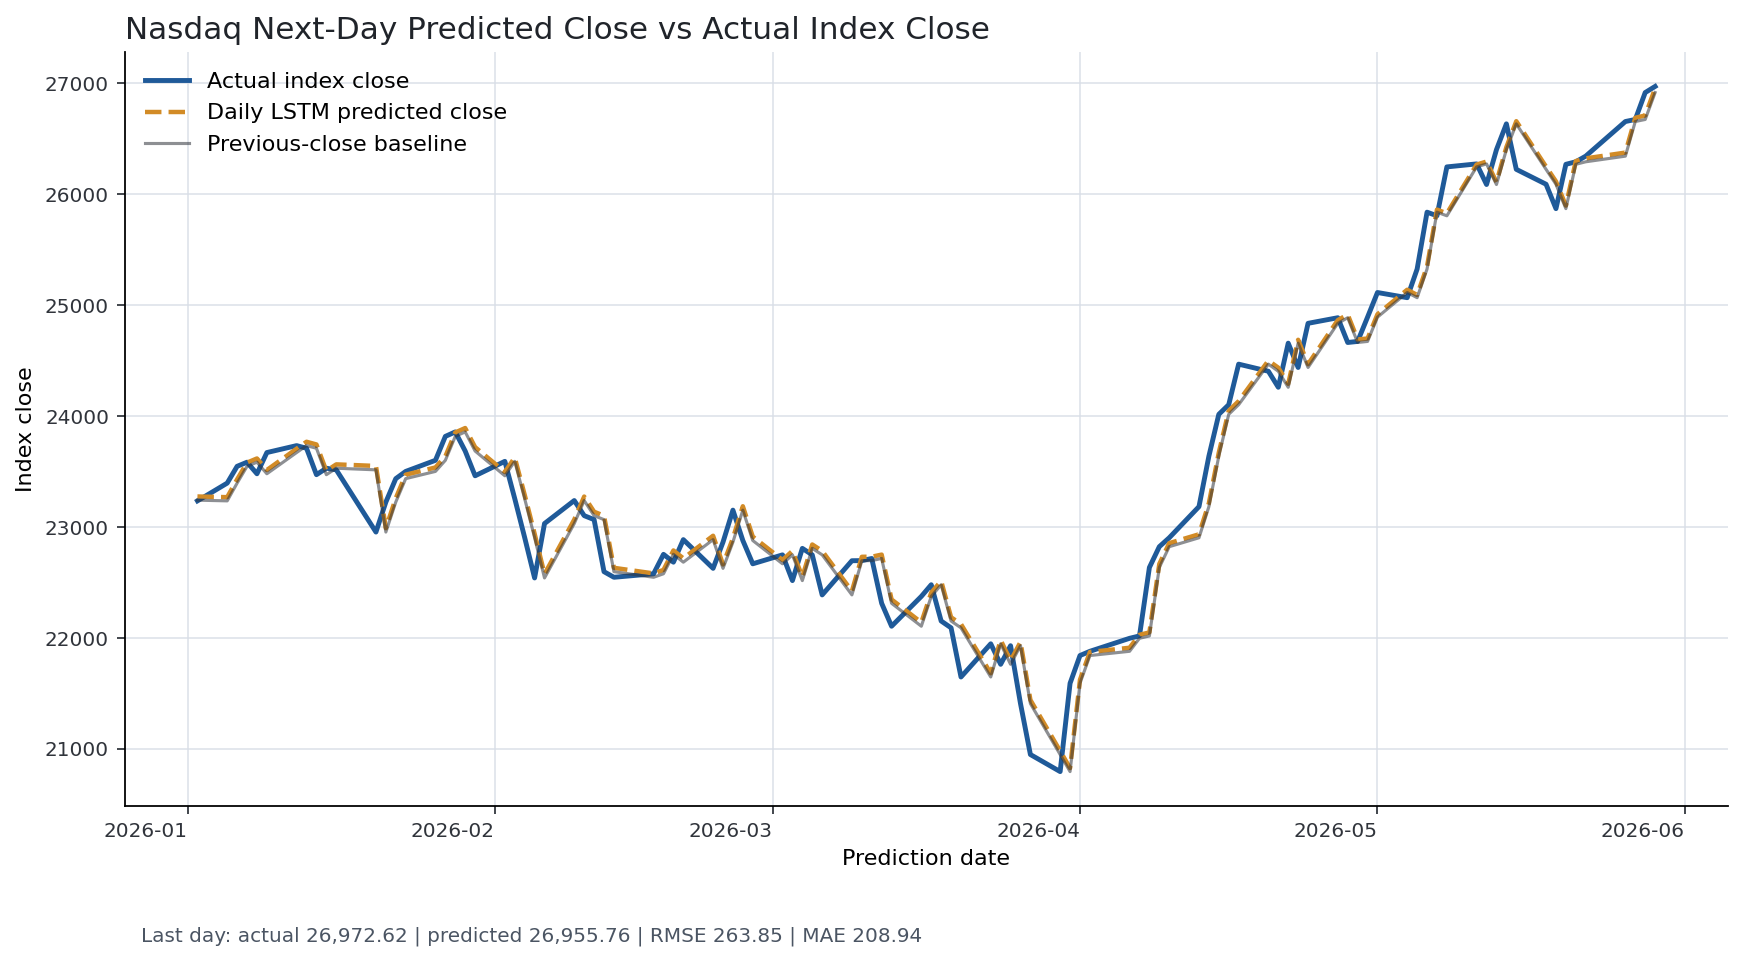

SP500


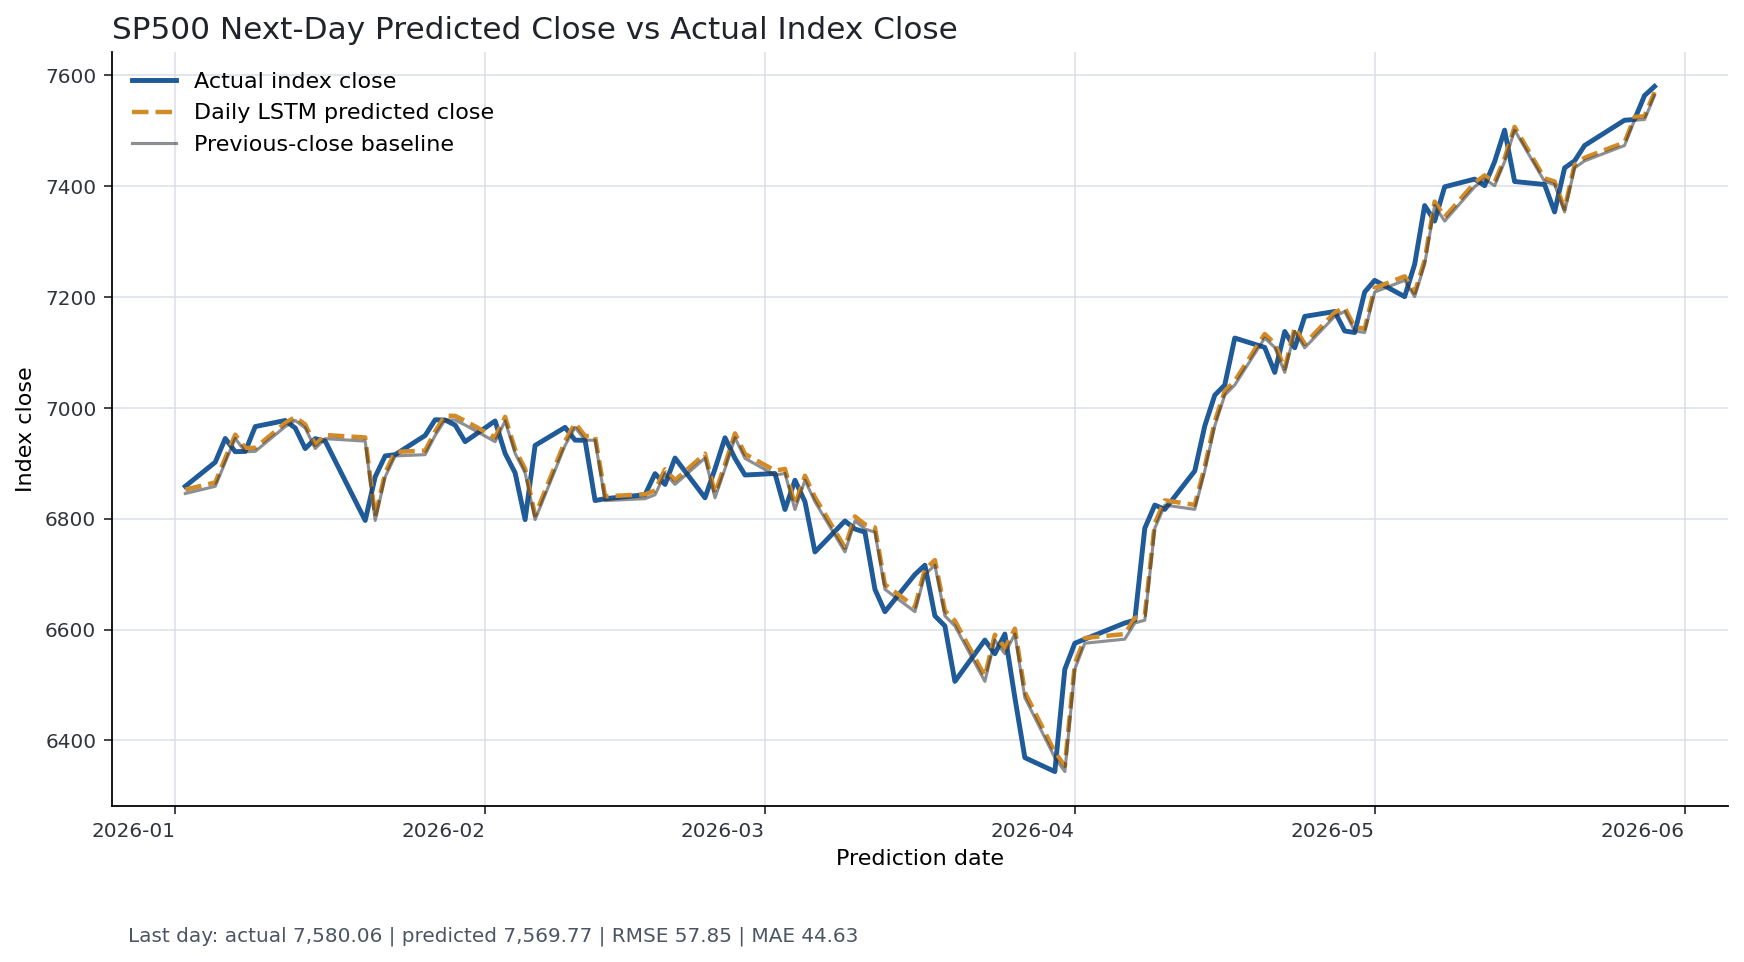

SOX


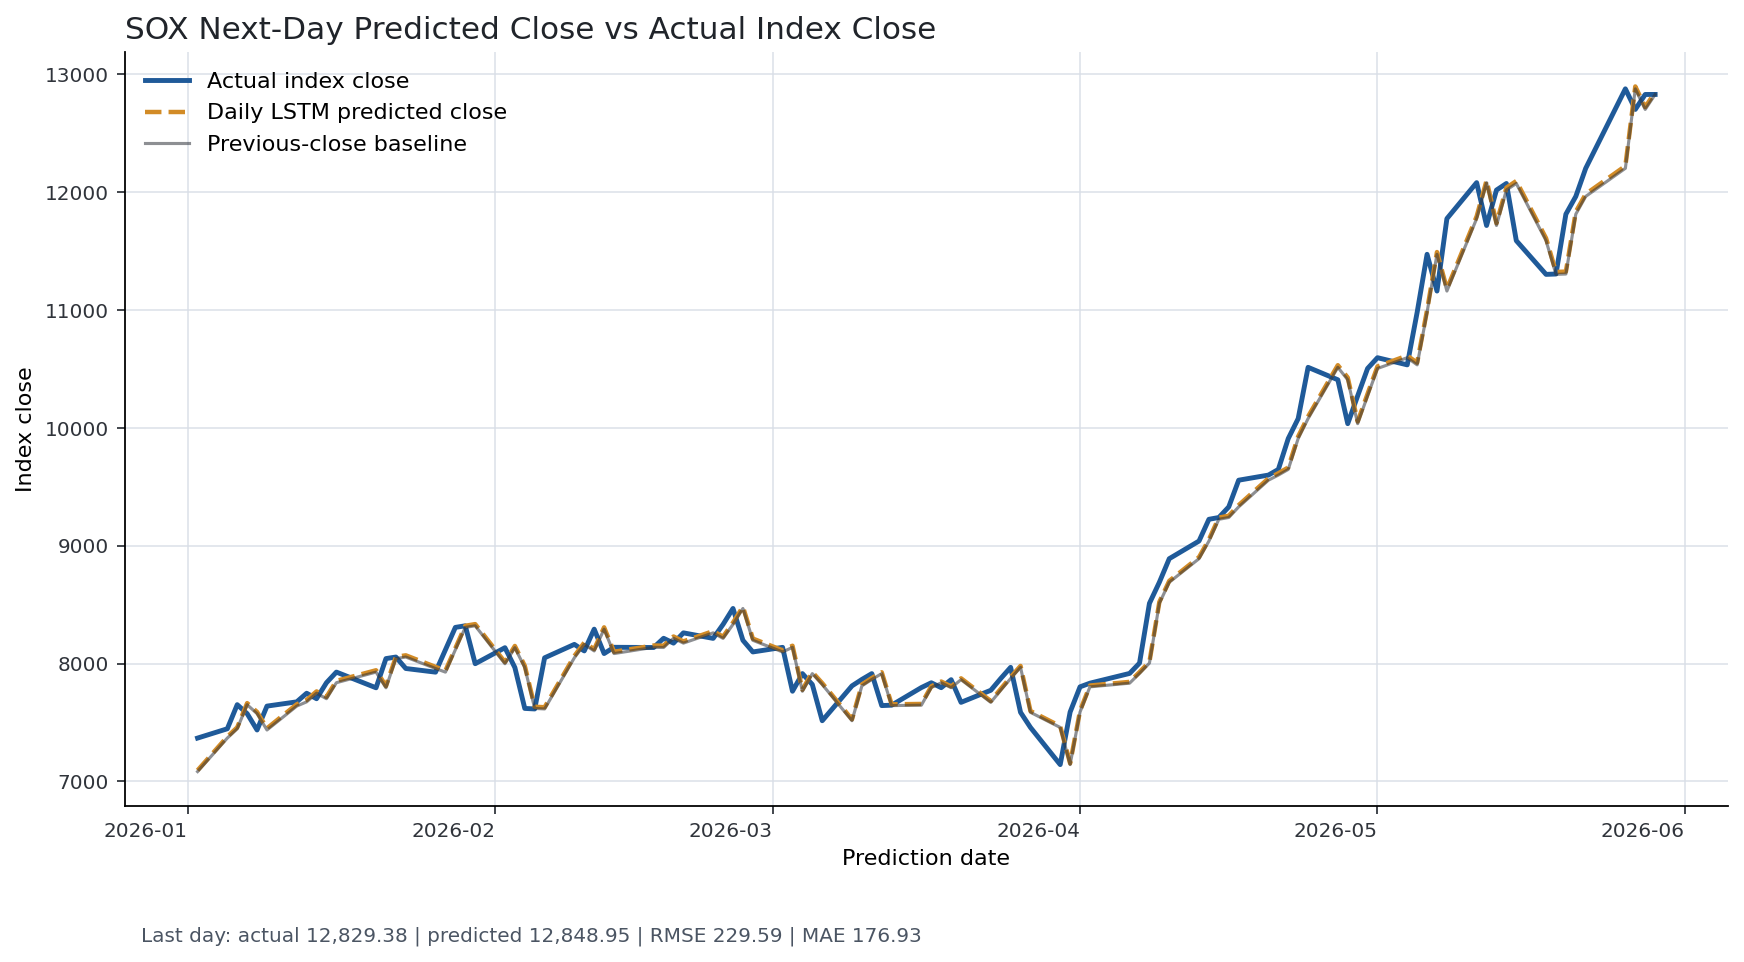

In [22]:
for index_name in summary["index"]:
    print(index_name)
    display(Image(filename=str(PLOTS_DIR / f"{index_name}_price_prediction.png")))
